# TensorFlow Lite model for Cats and Dogs classification

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/TensorFlow-Data_and_Deployment/portfolio-6.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Create a TFLite model that can classify images of cats and dogs.

**TensorFlow Lite** (now rebranded as [LiteRT](https://developers.google.com/edge/litert/overview)) is an open-source deep learning framework developed by Google designed for on-device inference (edge computing). It enables developers to deploy trained machine learning models directly on resource-constrained devices such as mobile phones, embedded systems, IoT devices, and microcontrollers without relying on cloud connectivity.

Key characteristics include:

- **Optimization**: It converts standard TensorFlow models into a compact `.tflite` format using techniques like quantization and pruning to reduce model size and memory usage.
- **Performance**: It ensures low latency and efficient execution by leveraging hardware acceleration and optimized kernels.
- **Cross-Platform Support**: It runs on Android, iOS, embedded Linux, and microcontrollers with support for languages like Java, Swift, C++, and Python.
- **Privacy & Connectivity**: By processing data locally, it enhances user privacy and functions without an internet connection. 

Unlike the full TensorFlow framework, which is used for building and training models on high-performance servers, TensorFlow Lite is strictly for running inference on already trained models. 

## Import libraries

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from keras import applications, Model, layers, Input
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from ai_edge_litert.interpreter import Interpreter
import seaborn as sns
sns.set_style("whitegrid")
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1783020944.706000   81609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783020944.739397   81609 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783020945.514145   81609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1783020946.750835   81609 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## Load the dataset

We use [TensorFlow Datasets](http://tensorflow.org/datasets) to load the cats and dogs dataset.

The `tfds.load` method downloads and caches the data, and returns a `tf.data.Dataset` object. These objects provide powerful, efficient methods for manipulating data and piping it into your model.

Since `"cats_vs_dog"` only has one defined split, `train`, we are going to divide that into (train, validation, test) with 80%, 10%, 10% of the data respectively.

In [2]:
(train_examples, validation_examples, test_examples), info = tfds.load('cats_vs_dogs',
                                                                       data_dir='/tmp/',
                                                                       with_info=True, 
                                                                       as_supervised=True, 
                                                                       split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'])

W0000 00:00:1782952850.012692  266372 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1782952850.105919  266372 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5773 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


## Data preprocessing

We use the `tf.image` module to format the images for the task, then we resize the images to a fixed input size, and rescale the input channels. Finally we shuffle and batch the data.

In [3]:
num_examples = info.splits['train'].num_examples
num_classes = info.features['label'].num_classes
class_names = ['cat', 'dog']
image_size = (224, 224)
batch_size = 32

format_image = lambda image, label: (tf.image.resize(image, image_size), label)

train_ds = train_examples.shuffle(num_examples // 4).map(format_image).batch(batch_size).prefetch(1)
validation_ds = validation_examples.map(format_image).batch(batch_size).prefetch(1)
test_ds = test_examples.map(format_image).batch(1)

## Visualize the dataset

I0000 00:00:1782952850.348300  266538 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


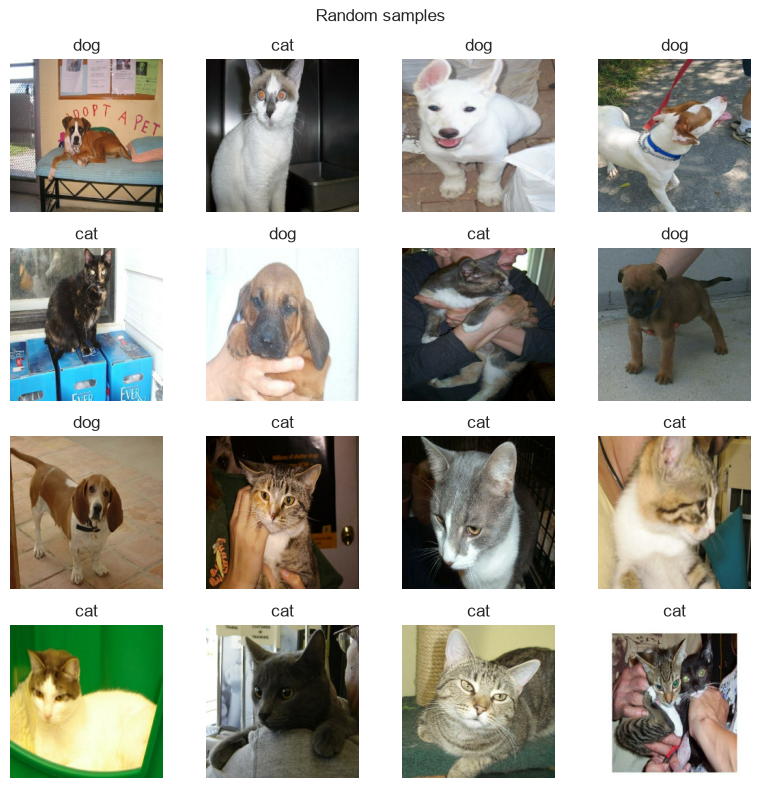

In [4]:
images, labels = next(iter(train_ds))

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Random samples')

for i, ax in enumerate(axs.flatten()):
    ax.imshow(images[i] / 255.0)
    ax.set_title(class_names[labels[i].numpy()])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize the class distribution

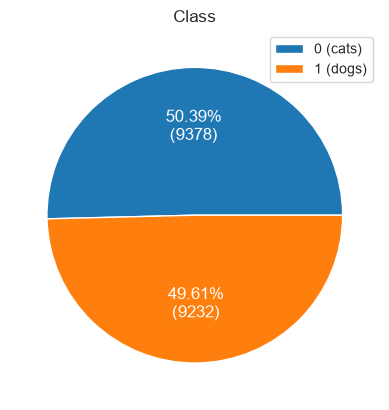

In [5]:
_, sizes = np.unique([labels.numpy() for _, labels in train_examples], return_counts=True)

fig, ax = plt.subplots()
ax.pie(sizes, textprops={'color': "w", 'fontsize': '12'}, autopct=lambda pct: "{:.2f}%\n({:d})".format(pct, round(pct/100 * sum(sizes))))
ax.legend(["0 (cats)", "1 (dogs)"])
ax.set_title("Class")
plt.show()

## Build the model

All it takes is to put a linear classifier on top of the a pre-trained [MobileNet V2](https://arxiv.org/pdf/1801.04381) as image `feature_extractor`.

For speed, we start out with a non-trainable `feature_extractor`.

In [6]:
input_shape = image_size + (3,)
MobileNetV2 = applications.MobileNetV2(include_top=False, input_shape=input_shape, pooling='avg')
MobileNetV2.trainable = False

inputs = Input(shape=input_shape)
x = applications.mobilenet_v2.preprocess_input(inputs) # Preprocess our images the same way the images used to train MobileNetV2 model were processed
x = MobileNetV2(x, training=False)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile and train the model

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

epochs = 5
history = model.fit(train_ds, epochs=epochs, validation_data=validation_ds)

Epoch 1/5


/home/luis-mendoza/GitHub/luisangelmendozavelasco.github.io/_portfolio/TensorFlow-Data_and_Deployment/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1782952857.447348  266515 service.cc:153] XLA service 0x7fae7005e880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782952857.447388  266515 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782952857.505558  266515 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782952858.013989  266515 cuda_dnn.cc:461] 

  6/582 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.6250 - loss: 0.6921 

I0000 00:00:1782952864.749578  266515 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9813 - loss: 0.0536

I0000 00:00:1782952876.430284  266520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45253__.117
E0000 00:00:1782952878.857839  266520 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9814 - loss: 0.0535

E0000 00:00:1782952888.590122  266515 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - accuracy: 0.9814 - loss: 0.0535 - val_accuracy: 0.9845 - val_loss: 0.0382
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9900 - loss: 0.0298 - val_accuracy: 0.9828 - val_loss: 0.0437
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9908 - loss: 0.0264 - val_accuracy: 0.9884 - val_loss: 0.0366
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9921 - loss: 0.0217 - val_accuracy: 0.9875 - val_loss: 0.0392
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9875 - val_loss: 0.0392


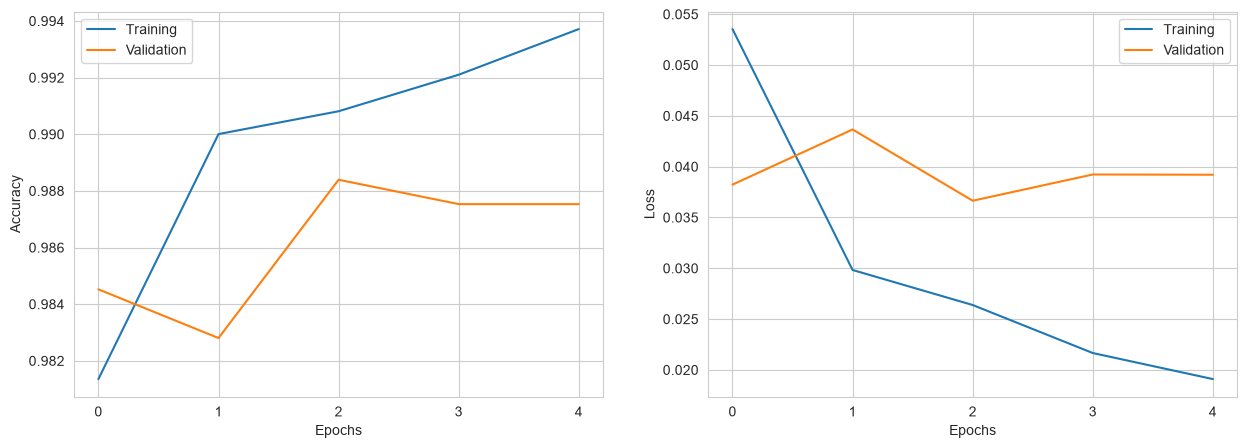

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xticks(range(epochs))
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend(["Training", "Validation"])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xticks(range(epochs))
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend(["Training", "Validation"])

plt.show()

## Convert the model into a TFLite model

Load the TFLiteConverter with the Keras model.

In [9]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

The simplest form of [post-training quantization](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_quantization) quantizes weights from floating point to 8-bits of precision. This technique is enabled as an option in the TensorFlow Lite converter. At inference, weights are converted from 8-bits of precision to floating point and computed using floating-point kernels. This conversion is done once and cached to reduce latency.

To further improve latency, hybrid operators [dynamically quantize](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_quantization#dynamic_range_quantization) activations to 8-bits and perform computations with 8-bit weights and activations. This optimization provides latencies close to fully fixed-point inference. However, the outputs are still stored using floating point, so that the speedup with hybrid ops is less than a full fixed-point computation.

In [10]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]

We can get further latency improvements, reductions in peak memory usage, and access to integer only hardware accelerators by making sure all model math is quantized using [integer quantization](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_integer_quant). To do this, we need to measure the dynamic range of activations and inputs with a representative data set. You can simply create an [input data generator](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_integer_quant#convert_using_float_fallback_quantization) and provide it to our converter.

In [11]:
def representative_data_gen():
    for input_value, _ in test_ds.take(100):
        yield [input_value]

converter.representative_dataset = representative_data_gen

The resulting model will be fully quantized but still take float input and output for convenience.

Ops that do not have quantized implementations will automatically be left in floating point. This allows conversion to occur smoothly but may restrict deployment to accelerators that support float.

To require the converter to only [output integer operations](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_quantization#integer_only), one can specify:

In [12]:
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

Finally, we convert the model and save it. The resulting model is a `.tflite` file that can be deployed to edge devices for inference.

In [ ]:
tflite_model = converter.convert()
tflite_model_file = '/tmp/model.tflite'

with open(tflite_model_file, "wb") as f:
    f.write(tflite_model)

## Evaluate the TFLite model

Load the TFLite model and allocate tensors.

In [14]:
interpreter = Interpreter(model_path=tflite_model_file)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]["index"]
output_details = interpreter.get_output_details()[0]["index"]

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Gather results for the test images.

In [15]:
test_predictions = []
test_labels, test_images = [], []

for image, label in tqdm(test_ds):
    interpreter.set_tensor(input_details, image)
    interpreter.invoke()

    test_predictions.append(interpreter.get_tensor(output_details))
    test_labels.append(label.numpy()[0])
    test_images.append(image)

100%|██████████| 2326/2326 [00:11<00:00, 210.01it/s]


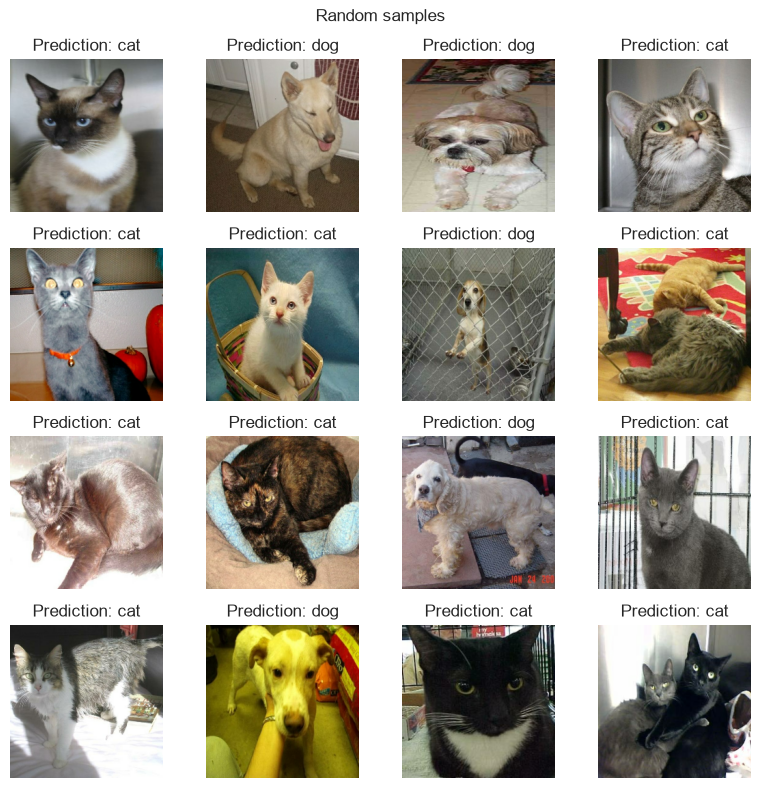

In [18]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Random samples')

for i, ax in enumerate(axs.flatten()):
    ax.imshow(test_images[i][0] / 255.0)
    ax.set_title("Prediction: " + class_names[np.argmax(test_predictions[i].squeeze())])
    ax.axis("off")

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0     0.9838    0.9940    0.9889      1160
           1     0.9939    0.9837    0.9888      1166

    accuracy                         0.9888      2326
   macro avg     0.9889    0.9888    0.9888      2326
weighted avg     0.9889    0.9888    0.9888      2326



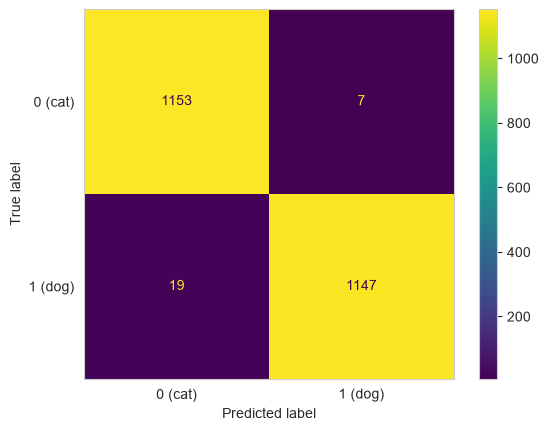

In [17]:
y_pred = [np.argmax(prediction.squeeze()) for prediction in test_predictions]

print(classification_report(test_labels, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(test_labels, y_pred, display_labels=["0 (cat)", "1 (dog)"])
plt.grid(False)
plt.show()